In [ ]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(ggplot2)
library(scRNAtoolVis)
library(ggpubr)
library(ggVolcano)
library(latex2exp)
library(ggrepel)
options(warn=-1)

In [4]:
sp <- readRDS("/DATA/User/liqian7/pienapple/04AS_updata/02figure2/02result/bulk_sample.RDS")

In [5]:
sp1 <- subset(sp,subset = sample=="save")

In [6]:
t <- read.csv("./CELL_PROLIFERATION.csv")####MSGDBR

In [7]:
gene <- colnames(t)
library(stringr)

In [8]:
library(stringr)
gene1 <-str_to_title(gene)

In [9]:
sp2 <- AddModuleScore(sp, features = list(gene1))

In [10]:
colnames(sp2@meta.data) <- str_replace(colnames(sp2@meta.data),"Cluster1","CELL_PROLIFERATION")

In [11]:
sp2@meta.data$week <- str_replace(sp2@meta.data$week,"con","N")
mer <- sp2@meta.data

In [12]:
mer1 <- subset(mer,subset = CELL_PROLIFERATION>0.2)

In [17]:
cp <-list(c('W20_N','W0'),c('W20_N','W2'),c('W20_N','W6'),c('W20_N','W10'),c('W20_N','W20'))

In [ ]:
#mer1 <-mer
order <- c('W20_N','W0','W2','W6','W10','W20')
cell_type_cols <- c('W0'= '#FFE3F0','W2'='#EFA5B9','W6'='#E4D7FF','W10'='#ABA0FB','W20'='#736DC2','W20_N'="#A1CFFA")

mer1$week <- factor(mer1$week, levels = order)
p1 <- ggplot(mer1,aes(x=week,y=CELL_PROLIFERATION,fill=week))+geom_boxplot(size=0.5) +

    labs()+scale_fill_manual(values = cell_type_cols)+geom_jitter(data = mer1, aes(y = CELL_PROLIFERATION),
              size = 1, shape = 21,
              color="black",
              stroke = 0.15, show.legend = FALSE, 
              position = position_jitterdodge())+
    theme_classic ()

In [29]:
p2 <-  p1+stat_compare_means(comparisons = list(c('W0','W20_N'),c('W20_N','W2'),c('W20_N','W6'),c('W20_N','W10'),c('W20_N','W20')),
                     label = "p.signif",
                     method ="t.test",
                     paired = FALSE,step.increase = 0.1,
                     method.args = list(p.adjust.method = "holm",
                                        alternative = "two.sided",
                                        var.equal=TRUE),
                     bracket.size =0.7,
                     size=5)+theme(axis.text = element_text (size = 20))+#
    theme(axis.title.x=element_text(vjust=0, size=25,face = "plain"))+#
    theme(axis.title.y=element_text(vjust=0, size=25,face = "plain"))+#
    theme(plot.title = element_text(size = 25, face = "bold"))+
    theme(axis.line = element_line(color = "black",linewidth = 0.8))+#
    theme(legend.title = element_text(size=20),  #
          legend.text = element_text(size=15))

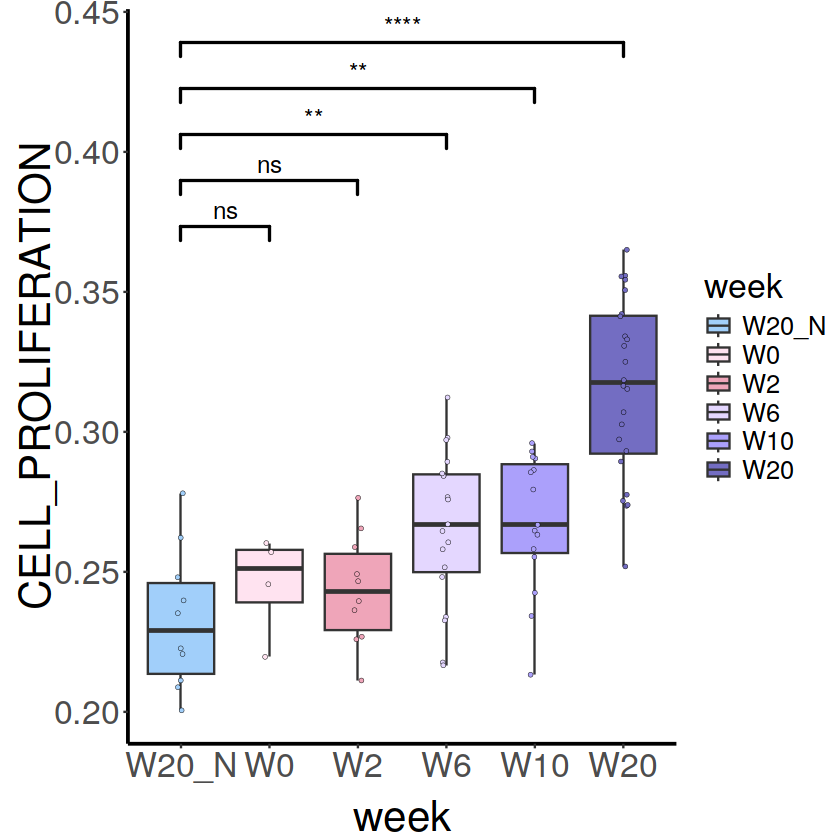

In [30]:
p2